Finding the formation efficency

In [1]:
#imports!

# let's import things
import h5py as h5 
import pandas as pd
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
import sys
import os
from scipy import stats
import seaborn as sns
import matplotlib as mpl
import tol_colors as tc

# Add the subdir to sys.path for our created scripts
sys.path.append('/home/msantiago/research_work/useful_py_scripts/')
sys.path.append('/home/msantiago/research_work/making_figures/paper_figures/')

# Now you can import the module
import useful_fncs
import utils_from_others
import figure_utils

# import for axes labels 
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

In [2]:
# let's read in our files 

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

DATA_SPS = Data_NSNS['BSE_System_Parameters']
# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [3]:
setllar_typesDCO_1 = DCOs_NSNS["Stellar_Type(1)"][()]
setllar_typesDCO_2 = DCOs_NSNS["Stellar_Type(2)"][()]

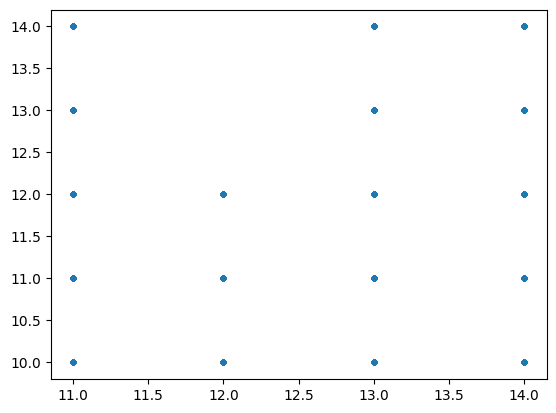

In [4]:
# checking the stellar types in DCO tbale
plt.plot(setllar_typesDCO_1, setllar_typesDCO_2, ".")

In [5]:
# we want to find how many merging NSNS systems there are

# times (these should be in Myr)
lifetimes_all = DCOs_NSNS['Time'][()]
lifetimes = lifetimes_all[DCO_mask_NSNS]

col_times_all = DCOs_NSNS['Coalescence_Time'][()]
col_times = col_times_all[DCO_mask_NSNS]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times = lifetimes + col_times

hubble_time = 13.9e3 # this is Myrs
condition_mergers = delay_times < hubble_time
mergers = np.sum(condition_mergers)

In [10]:
# selecting for NSNS
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1 = stellar_types_all_1[DCO_mask_NSNS]
stellar_types_1_merged = stellar_types_1[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2 = stellar_types_all_2[DCO_mask_NSNS]
stellar_types_2_merged = stellar_types_2[condition_mergers]

In [7]:
# making sure we are rpesenting the true universe
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixture_weights = mixture_weights_all[DCO_mask_NSNS]

In [11]:
# now we want to figure out how many NSNS systems merge within a hubble time

NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)
np.sum(NSNS_systems_bool)


np.int64(162650)

In [46]:
# all__metallicities = Data_NSNS['BSE_System_Parameters']['Metallicity@ZAMS(1)'][()]
# unique_Z, counts_per_Z = np.unique(all__metallicities, return_counts=True)

In [15]:
df = pd.DataFrame({key: DCOs_NSNS[key][:] for key in DCOs_NSNS.keys()})

In [48]:
df_SPs = pd.DataFrame({key: DATA_SPS[key][:] for key in DATA_SPS.keys()})

In [50]:
counts_bins_metals = pd.cut(np.log10(df_SPs['Metallicity@ZAMS(1)']), bins=100).value_counts(sort=False)
counts_bins_metals

Metallicity@ZAMS(1)
(-4.002, -3.975]    50228
(-3.975, -3.95]     50546
(-3.95, -3.926]     50774
(-3.926, -3.901]    50886
(-3.901, -3.876]    50820
                    ...  
(-1.647, -1.622]    48876
(-1.622, -1.597]    48864
(-1.597, -1.572]    48642
(-1.572, -1.548]    48912
(-1.548, -1.523]    48708
Name: count, Length: 100, dtype: int64

In [59]:
# # get avergage star forming mass per binary

# def get_totalMassInStarFormation(x2=0.08, x3=0.5, a1=-0.3, a2=-1.3, a3=-2.3, C1=1.,
#                          Mmin_universe=0.01, Mmax_universe=300., sampleSize=2000000):
#     """_summary_

#     Args:
#         # COMPAS simulation parameters
#         pathCOMPASh5 (_type_, optional): path to your COMPAS file. Defaults to None.

#         # Broken powerlaw (Kroupa IMF) parameters
#         x1, x2, x3, x4: float, the break points (mass ranges) for the three segments
#         a1, a2, a3: float, the power law indices 
#         <0.01 - 0.08> a = -0.3, <0.08 - 0.5> a = -1.3, <0.5 - 200> a = -2.3
#         C1: float, the normalization constant for the first segment
        
#         # Believes about star formation in the Universe
#         binaryFraction (int, optional): What fraction of stars are in binaries. Default= 1.
#         Mmin_universe, Mmax_universe (float): the min and max mass that stars in the Universe can be born with  Defaults: 0.01 and 200.

#     Returns:
#         _type_: _description_
#     """ 
#     x1 = Mmin_universe
#     x4 = Mmax_universe

#     ##########################
#     # Create Sample Universe 
#     ##########################
#     # we will use 'inverse transform sampling method' to sample our sample Universe from the IMF

#     ### Primary mass
#     # first we compute the y-values of the CDF of our IMF at Mmin_universe and Mmax_universe
#     # Mmin_universe and Mmax_universe have to be between x1 and x4
#     CDFmin = CDFbrokenPowerLaw(np.array([Mmin_universe]), x1, x2, x3, x4, a1, a2, a3, C1)
#     CDFmax = CDFbrokenPowerLaw(np.array([Mmax_universe]), x1, x2, x3, x4, a1, a2, a3, C1)


#     # Now we can sample Uniformly from the CDF between CDFmin and CDFmax
#     drawM1      = np.random.uniform(CDFmin,CDFmax,sampleSize)
#     # Convert CDF values back to masses
#     M1          = invertCDFbrokenPowerLaw(drawM1, x1, x2, x3, x4, a1, a2, a3, C1)

#     ### Secondary mass
#     # mass ratio (q = m2/m1) distribution is assumed to be flat 
#     # so then the drawM2 (if it is in a binary) just becomes the mass fraction.
#     drawM2          = np.random.uniform(0,1,sampleSize)    # we are actually sampling q
#     M2              = np.zeros(sampleSize)                 # are zeros, but will be filled with binary fraction

#     ### Binary fraction
#     # we want that binaryFraction of the stars are in binaries
#     # Hence by drawing between 0-1, we have to throw out everything that is above binaryFraction (i.e. = single and m2 = 0)
#     # to incorporate the mass dependence of f_binary, we bin our samples in mass and draw a binary fraction for each bin
#     binary_bin_edges    = [x1, 0.08, 0.5, 1, 10, x4]
#     # binaryFractions     = [0.1, 0.25, 0.5, 0.75, 1]
#     binaryFractions = [0.70]

#     # for m_i in range(len(binary_bin_edges[:-1])):
#     #     m1_mask = (M1 >= binary_bin_edges[m_i]) & (M1 < binary_bin_edges[m_i+1])
#     #     drawBinary = np.random.uniform(0,1,np.sum(m1_mask)) # draw a binary for all the samples in this mass bin
#     #     maskBinary = drawBinary < binaryFractions[m_i]
        
#     #     # if maskBinary is True, then M2 = q * m1, else M2 = 0
#     #     M2[m1_mask] = np.where(maskBinary, drawM2[m1_mask] * M1[m1_mask], 0)

#     totalMassInStarFormation = np.sum(M1) + np.sum(M2)

#     return totalMassInStarFormation


# def CDFbrokenPowerLaw(x, x1=0.01, x2=0.08, x3=0.5, x4=200, a1=-0.3, a2=-1.3, a3=-2.3, C1=1):
#     """
#     CDF values of a three-part broken powerlaw representing a Kroupa IMF by default.
    
#     Parameters:
#     x: array-like, the input values
#     x1, x2, x3, x4: float, the break points (mass ranges) for the three segments
#     a1, a2, a3: float, the power law indices 
#     C1: float, the normalization constant for the first segment
    
#     Returns:
#     yvalues: array-like, the output values of the CDF
#     """

#     # Initialize the output array
#     yvalues = np.zeros(len(x))
    
#     # Calculate the normalization constants for the other segments
#     # Ensuring that the next segments start where the previous segment ends
#     C2 = float(C1 * (x2**(a1-a2)))
#     C3 = float(C2 * (x3**(a2-a3)))
    
#     # Calculate the normalization factors for the three segments
#     N1 = float(((1./(a1+1)) * C1 * (x2**(a1+1))) - ((1./(a1+1)) * C1 * (x1**(a1+1))))
#     N2 = float(((1./(a2+1)) * C2 * (x3**(a2+1))) - ((1./(a2+1)) * C2 * (x2**(a2+1))))
#     N3 = float(((1./(a3+1)) * C3 * (x4**(a3+1))) - ((1./(a3+1)) * C3 * (x3**(a3+1))))
    
#     # Calculate the denominator of the CDF
#     bottom = N1+N2+N3
    
#     # Calculate the CDF values for x range: x1<=x<x2
#     mask1 = (x>=x1) & (x<x2)
#     top1 = ( (1./(a1+1) ) * C1 * (x[mask1]**(a1+1) ) - (1./(a1+1) ) * C1 * (x1**(a1+1) ) ) 
#     yvalues[mask1] = top1/bottom
    
#     # Calculate the CDF values for x range: x2<=x<x3
#     mask2 = (x>=x2) & (x<x3)
#     top2 =  N1 + ( (1./(a2+1) ) * C2 * (x[mask2]**(a2+1) ) - (1./(a2+1)) * C2 * (x2**(a2+1) ) ) 
#     yvalues[mask2] = top2/bottom
    
#     # Calculate the CDF values for x range: x3<=x<=x4
#     mask3 = (x>=x3) & (x<=x4)
#     top3 =  N1 + N2 + ( (1./(a3+1)) * C3 * (x[mask3]**(a3+1)) - (1./(a3+1)) * C3 * (x3**(a3+1) ) )
#     yvalues[mask3] = top3/bottom
    
#     return yvalues

# def invertCDFbrokenPowerLaw(CDF, x1, x2, x3, x4, a1, a2, a3, C1):
#     """
#     Invert y-values of a CDF back to x-vals (i.e. the masses)
#     Specifically for a three-part piece-wise powerlaw representing a Kroupa IMF by default. 

#     Parameters:
#     CDF: array-like, the CDF values to invert
#     x1, x2, x3, x4: float, the break points (ranges) for the three segments
#     a1, a2, a3: float, the power law indices for the three segments
#     C1: float, the normalization constant for the first segment

#     Returns:
#     xvalues: array-like, the inverted CDF values
#     """
    
#     # Calculate the normalization constants for the second and third segments
#     C2 = float(C1 * (x2**(a1-a2)))
#     C3 = float(C2 * (x3**(a2-a3)))
    
#     # Calculate the area under the curve for each segment
#     N1 = float(((1./(a1+1)) * C1 * (x2**(a1+1))) - ((1./(a1+1)) * C1 * (x1**(a1+1))))
#     N2 = float(((1./(a2+1)) * C2 * (x3**(a2+1))) - ((1./(a2+1)) * C2 * (x2**(a2+1))))
#     N3 = float(((1./(a3+1)) * C3 * (x4**(a3+1))) - ((1./(a3+1)) * C3 * (x3**(a3+1))))
    
#     # Calculate the CDF values at the breakpoints
#     CDFx2 = CDFbrokenPowerLaw(np.array([x2,x2]), x1, x2, x3, x4, a1, a2, a3, C1)[0]
#     CDFx3 = CDFbrokenPowerLaw(np.array([x3,x3]), x1, x2, x3, x4, a1, a2, a3, C1)[0]

#     # Initialize the output array
#     xvalues = np.zeros(len(CDF))
    
#     # Calculate the inverse CDF values for the first segment
#     mask1 = (CDF < CDFx2)
#     xvalues[mask1] =  (((CDF[mask1]*(N1+N2+N3))  + \
#                       ( (1./(a1+1))*C1*(x1**(a1+1))))/((1./(a1+1))*C1))**(1./(a1+1))
    
#     # Calculate the inverse CDF values for the second segment
#     mask2 = (CDFx2<= CDF) & (CDF < CDFx3)
#     xvalues[mask2] = ((((CDF[mask2]*(N1+N2+N3))-(N1))  + \
#                       ( (1./(a2+1))*C2*(x2**(a2+1))))/((1./(a2+1))*C2))**(1./(a2+1))
    
#     # Calculate the inverse CDF values for the third segment
#     mask3 = (CDFx3<= CDF) 
#     xvalues[mask3] = ((((CDF[mask3]*(N1+N2+N3))-(N1+N2))  + \
#                       ((1./(a3+1))*C3*(x3**(a3+1))))/((1./(a3+1))*C3))**(1./(a3+1))
    
#     # Return the inverse CDF values
#     return xvalues

In [63]:
# Sampe_size = int(5e6)
# totalMassInStarFormation =  get_totalMassInStarFormation(Mmin_universe=5, Mmax_universe=150, sampleSize=Sampe_size)

# average_mass_per_system_univ = totalMassInStarFormation/Sampe_size
# print(f'Average mass per system in Universe {average_mass_per_system_univ}' )

In [60]:
###################################################
# New version of analytical calculation
###################################################
def analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=1., imf_mass_bounds=[0.01,0.08,0.5,200]
):
    """
    Analytical computation of the mass of stars formed per binary star formed within the
    [m1 min, m1 max] and [m2 min, ..] rage,
    using the Kroupa IMF:

        p(M) \propto M^-0.3 for M between m1 and m2
        p(M) \propto M^-1.3 for M between m2 and m3;
        p(M) = alpha * M^-2.3 for M between m3 and m4;

    m1_min, m1_max are the min and max sampled primary masses
    m2_min is the min sampled secondary mass

    This function further assumes a flat mass ratio distribution with qmin = m2_min/m1, and  m2_max = m1_max
    Lieke base on Ilya Mandel's derivation
    """
    # Kroupa IMF 
    m1, m2, m3, m4 = imf_mass_bounds
    continuity_constants = [1./(m2*m3), 1./(m3), 1.0]  
    IMF_powers = [-0.3, -1.3, -2.3]  

    if m1_min < m3:
        raise ValueError(f"This analytical derivation requires IMF break m3  < m1_min ({m3} !< {m1_min})")
    if m1_min > m1_max:
        raise ValueError(f"Minimum sampled primary mass cannot be above maximum sampled primary mass: m1_min ({m1_min} !<  m1_max {m1_max})")
    if m1_max > m4:
        raise ValueError(f"Maximum sampled primary mass cannot be above maximum mass of Kroupa IMF:  m1_max ({m1_max} !<  m4 {m4})")
    
    # normalize IMF over the complete mass range:
    alpha = (-(m4**(-1.3)-m3**(-1.3))/1.3 - (m3**(-0.3)-m2**(-0.3))/(m3*0.3) + (m2**0.7-m1**0.7)/(m2*m3*0.7))**(-1)
    # print('alpha', alpha)

    # we want to compute M_stellar_sys_in_universe / N_binaries_in_COMPAS
    #  = N_binaries_in_universe/N_binaries_in_COMPAS * N_stellar_sys_in_universe/N_binaries_in_universe * M_stellar_sys_in_universe/N_stellar_sys_in_universe
    #  = 1/fint * 1/fbin * average mass of a stellar system in the Universe

    # fint =  N_binaries_in_COMPAS/N_binaries_in_universe: fraction of binaries that COMPAS simulates
    fint = -alpha / 1.3 * (m1_max ** (-1.3) - m1_min ** (-1.3)) + alpha * m2_min / 2.3 * (m1_max**(-2.3) - m1_min **(-2.3))


    # Next for N_stellar_sys_in_universe/N_binaries_in_universe * M_stellar_sys_in_universe/N_stellar_sys_in_universe
    # N_stellar_sys_in_universe/N_binaries_in_universe = the binary fraction 
    # fbin edges and values are chosen to approximately follow Figure 1 from Offner et al. (2023)
    binary_bin_edges = [m1, 0.08, 0.5, 1, 10, m4]    
    if isinstance(fbin, (int, float)):
        # Constant binary fraction
        binaryFractions = [fbin] * 5
    else:
        # Variable binary fraction with mass
        binaryFractions = [0.1, 0.225, 0.5, 0.8, 1.0] 


    # M_stellar_sys_in_universe/N_stellar_sys_in_universe = average mass of a stellar system in the Universe,
    # we are computing 1/fbin * M_stellar_sys_in_universe/N_stellar_sys_in_universe, skipping steps this leads to:
    # int_A^B (1/fb(m1) + 0.5) m1 P(m1) dm1. 
    # This is a double piecewise integral, i.e. pieces over the binary fraction bins and IMF mass bins.
    piece_wise_integral = 0

    # For every binary fraction bin
    for i in range(len(binary_bin_edges) - 1):
        fbin = binaryFractions[i] # Binary fraction for this range

        # And every piece of the Kroupa IMF
        for j in range(len(imf_mass_bounds) - 1):
            exponent = IMF_powers[j] # IMF exponent for these masses

            # Check if the binary fraction bin overlaps with the IMF mass bin
            if binary_bin_edges[i + 1] <= imf_mass_bounds[j] or binary_bin_edges[i] >= imf_mass_bounds[j + 1]:
                continue  # No overlap

            # Integrate from the most narrow range
            m_start = max(binary_bin_edges[i], imf_mass_bounds[j])
            m_end = min(binary_bin_edges[i + 1], imf_mass_bounds[j + 1])
            print("Integrating from", m_start, "to", m_end, "for fbin =", fbin, "and exponent =", exponent)

            # Compute the definite integral:
            integral = ( m_end**(exponent + 2) - m_start**(exponent + 2) ) / (exponent + 2) * continuity_constants[j]

            # Compute the sum term
            sum_term = (1 /fbin + 0.5) * integral
            piece_wise_integral += sum_term

    # combining them:
    Average_mass_stellar_sys_per_fbin = alpha * piece_wise_integral

    # Now compute the average mass per binary in COMPAS M_stellar_sys_in_universe / N_binaries_in_COMPAS
    M_sf_Univ_per_N_binary_COMPAS = (1/fint) * Average_mass_stellar_sys_per_fbin

    return M_sf_Univ_per_N_binary_COMPAS

In [61]:
print(max(Data_NSNS['BSE_System_Parameters']['Mass@ZAMS(1)'][()]))
print(min(Data_NSNS['BSE_System_Parameters']['Mass@ZAMS(1)'][()]))
print(min(Data_NSNS['BSE_System_Parameters']['Mass@ZAMS(2)'][()]))

149.99930429323493
5.000000088386589
0.10000213157468987


In [65]:
analytical_star_forming_mass_per_binary = analytical_star_forming_mass_per_binary_using_kroupa_imf(5, 150, 0.1, fbin=0.7)
analytical_star_forming_mass_per_binary

Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3


101.71305071633428

In [66]:
counts_bins_metals/((5e6)*analytical_star_forming_mass_per_binary)

Metallicity@ZAMS(1)
(-4.002, -3.975]    0.000099
(-3.975, -3.95]     0.000099
(-3.95, -3.926]     0.000100
(-3.926, -3.901]    0.000100
(-3.901, -3.876]    0.000100
                      ...   
(-1.647, -1.622]    0.000096
(-1.622, -1.597]    0.000096
(-1.597, -1.572]    0.000096
(-1.572, -1.548]    0.000096
(-1.548, -1.523]    0.000096
Name: count, Length: 100, dtype: float64

In [83]:
# we can get the Average_SF_mass_needed to get the number of systems we have
efficencies_perbin = counts_bins_metals/((5e6)*analytical_star_forming_mass_per_binary)

#the centers of each bin
center_bins = []
for i in range(len(counts_bins_metals)):
    bin_range = str(efficencies_perbin.index[i]).strip('(]').split(',')
    left_edge = float(bin_range[0])
    right_edge = float(bin_range[1])

    bin_centers_int = (left_edge + right_edge) / 2
    center_bins.append(bin_centers_int)


Text(0.5, 0, 'Metallicity $\\log_{10}(Z/Z_{\\odot})$')

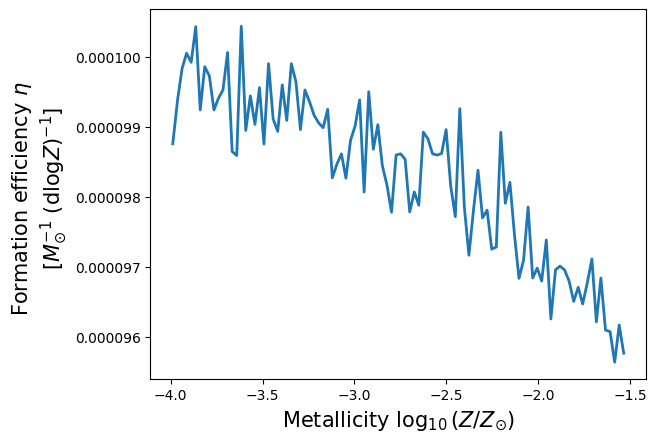

In [94]:
# let's actually plot this
plt.plot(center_bins, efficencies_perbin.values, lw=2)


# plt.yscale('log')
#plt.ylim(10**-8, 10**-5)

plt.ylabel('Formation efficiency $\eta$  \n  $[M_{\odot}^{-1} \ (\mathrm{dlog}Z)^{-1}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z/Z_{\odot})$', fontsize=15)



#### let's do the same for the WDWD systems

In [95]:
# let's read in our files 

## WDWD optimized run

pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

In [97]:
# times (these should be in Myr)
lifetimes_all_WDWD = DCOs_WDWD['Time'][()]
lifetimes_WDWD = lifetimes_all_WDWD[DCO_mask_WDWD]

col_times_all_WDWD = DCOs_WDWD['Coalescence_Time'][()]
col_times_WDWD = col_times_all_WDWD[DCO_mask_WDWD]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_WDWD = lifetimes_WDWD + col_times_WDWD

condition_mergers_WDWD = delay_times_WDWD < hubble_time
mergers_WDWD = np.sum(condition_mergers_WDWD)

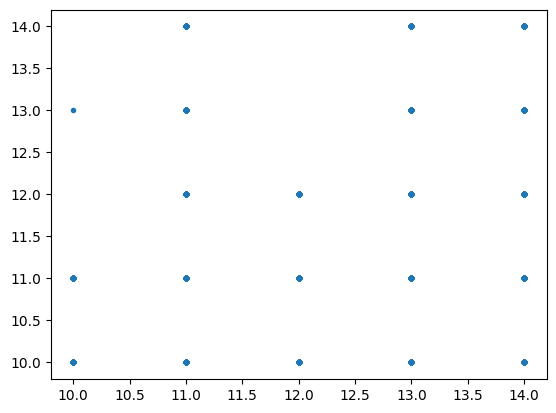

In [98]:
# making sure the DCO is all types
setllar_typesDCO_1 = DCOs_WDWD["Stellar_Type(1)"][()]
setllar_typesDCO_2 = DCOs_WDWD["Stellar_Type(2)"][()]

plt.plot(setllar_typesDCO_1, setllar_typesDCO_2, ".")

In [99]:
stellar_types_all_1_WDWD = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_WDWD = stellar_types_all_1_WDWD[DCO_mask_WDWD]
stellar_types_1_merged_WDWD = stellar_types_1_WDWD[condition_mergers_WDWD]

stellar_types_all_2_WDWD = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_WDWD = stellar_types_all_2_WDWD[DCO_mask_WDWD]
stellar_types_2_merged_WDWD = stellar_types_2_WDWD[condition_mergers_WDWD]

In [100]:
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDWD, stellar_types_2_merged_WDWD)
carbon_oxygen_bool_WDWD = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

np.sum(carbon_oxygen_bool_WDWD)

np.int64(2496402)

In [101]:
df_SPs_WDWD = pd.DataFrame({key: DATA_SPS_WDWD[key][:] for key in DATA_SPS_WDWD.keys()})

In [103]:
counts_bins_metals_WDWD = pd.cut(np.log10(df_SPs_WDWD['Metallicity@ZAMS(1)']), bins=100).value_counts(sort=False)
counts_bins_metals_WDWD

Metallicity@ZAMS(1)
(-4.002, -3.975]    49783
(-3.975, -3.95]     50397
(-3.95, -3.926]     50435
(-3.926, -3.901]    49987
(-3.901, -3.876]    50457
                    ...  
(-1.647, -1.622]    49867
(-1.622, -1.597]    50040
(-1.597, -1.572]    50066
(-1.572, -1.548]    49595
(-1.548, -1.523]    49626
Name: count, Length: 100, dtype: int64

In [104]:
print(max(Data_WDWD['BSE_System_Parameters']['Mass@ZAMS(1)'][()]))
print(min(Data_WDWD['BSE_System_Parameters']['Mass@ZAMS(1)'][()]))
print(min(Data_WDWD['BSE_System_Parameters']['Mass@ZAMS(2)'][()]))

149.8125979468025
1.0000002299973298
0.10000258026110291


In [105]:
analytical_star_forming_mass_per_binary_WDWD = analytical_star_forming_mass_per_binary_using_kroupa_imf(1, 150, 0.1, fbin=0.7)
analytical_star_forming_mass_per_binary_WDWD

Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3


13.014304811861441

In [106]:
# we can get the Average_SF_mass_needed to get the number of systems we have
efficencies_perbin_WDWD = counts_bins_metals_WDWD/((5e6)*analytical_star_forming_mass_per_binary_WDWD)

#the centers of each bin
center_bins_WDWD = []
for i in range(len(counts_bins_metals_WDWD)):
    bin_range = str(efficencies_perbin_WDWD.index[i]).strip('(]').split(',')
    left_edge = float(bin_range[0])
    right_edge = float(bin_range[1])

    bin_centers_int = (left_edge + right_edge) / 2
    center_bins_WDWD.append(bin_centers_int)


Text(0.5, 0, 'Metallicity $\\log_{10}(Z/Z_{\\odot})$')

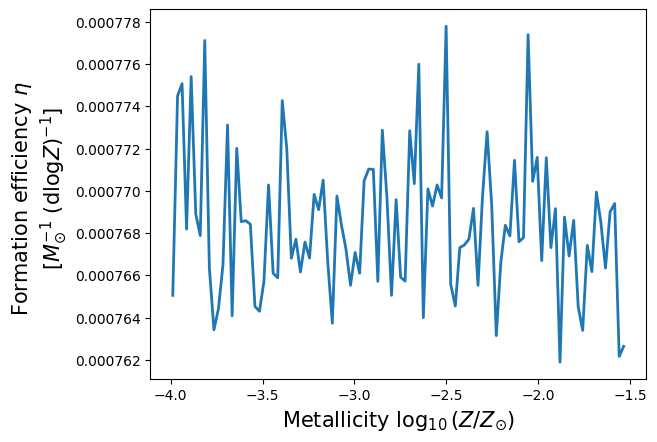

In [109]:
# let's actually plot this
plt.plot(center_bins_WDWD, efficencies_perbin_WDWD.values, lw=2)


# plt.yscale('log')
#plt.ylim(10**-8, 10**-5)

plt.ylabel('Formation efficiency $\eta$  \n  $[M_{\odot}^{-1} \ (\mathrm{dlog}Z)^{-1}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z/Z_{\odot})$', fontsize=15)



Text(0.5, 0, 'Metallicity $\\log_{10}(Z/Z_{\\odot})$')

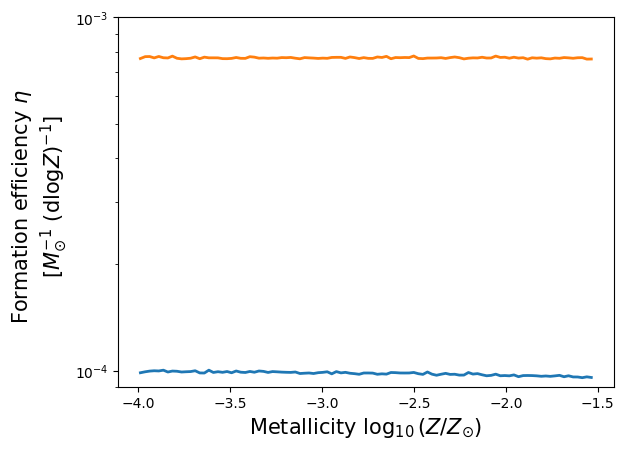

In [120]:
# let's now show both formation efficencies overplotted

plt.plot(center_bins, efficencies_perbin.values, lw=2)
plt.plot(center_bins_WDWD, efficencies_perbin_WDWD.values, lw=2)
4
plt.yscale('log')
plt.ylim(9e-5, 10**-3)

plt.ylabel('Formation efficiency $\eta$  \n  $[M_{\odot}^{-1} \ (\mathrm{dlog}Z)^{-1}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z/Z_{\odot})$', fontsize=15)